# Cyclic voltammetry: the classic duck

A cyclic voltammogram sweeps the potential up and back at a constant rate and records the current. For a soluble redox couple `O + n e⁻ ⇌ R` the current is set by **semi-infinite diffusion** of O and R to the electrode with a Butler-Volmer surface boundary condition: the current rises with overpotential, **peaks** as the surface depletes, then decays with a Cottrell tail, and on the return sweep the accumulated product is reconverted. That peak-and-return shape is the duck. `discopt_mkm.electrochem.cyclic_voltammogram` integrates the diffusion equation (an implicit finite-difference scheme) with the same Butler-Volmer kinetics used elsewhere, so `k0`, `α`, `n` mean the same thing.

This is the **transient** transport picture; the rotating disk notebook (17) is its steady-state counterpart.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
%matplotlib inline

## Reversible, quasi-reversible, irreversible

The shape is a fingerprint of the electron-transfer rate `k0`. Fast (reversible) gives a sharp, nearly symmetric duck with a small peak separation; slower kinetics push the cathodic and anodic peaks apart and draw them out.

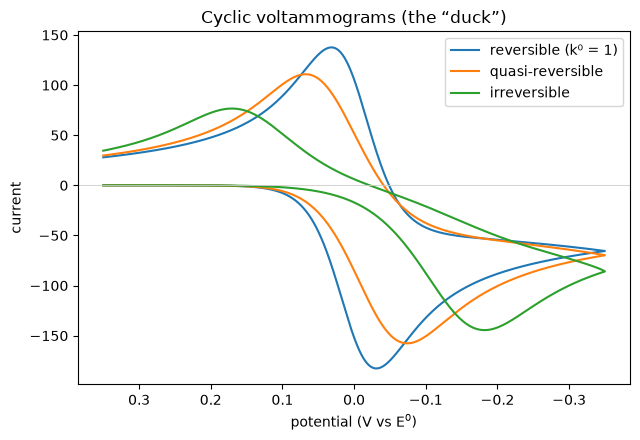

In [2]:
import numpy as np, matplotlib.pyplot as plt
from discopt_mkm.electrochem import cyclic_voltammogram

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for k0, lab in [(1.0, 'reversible (k⁰ = 1)'), (2e-3, 'quasi-reversible'), (2e-4, 'irreversible')]:
    U, i = cyclic_voltammogram(k0=k0, scan_rate=0.05, U_start=0.35, U_vertex=-0.35)
    ax.plot(U, i, label=lab)
ax.axhline(0, color='0.8', lw=0.6); ax.invert_xaxis()
ax.set_xlabel('potential (V vs E$^0$)'); ax.set_ylabel('current')
ax.set_title('Cyclic voltammograms (the \u201cduck\u201d)'); ax.legend()
fig.tight_layout()

## Scan-rate dependence and Randles-Sevcik

Faster sweeps draw current from a thinner depletion layer, so the peaks grow. For a reversible couple the peak current obeys **Randles-Sevcik**, `i_p ∝ √(scan rate)`.

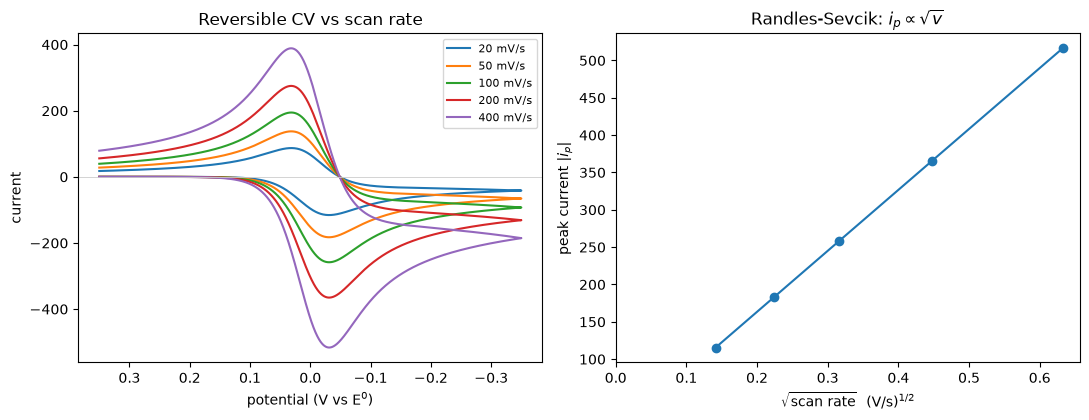

In [3]:
scan_rates = [0.02, 0.05, 0.1, 0.2, 0.4]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.3))
ip = []
for v in scan_rates:
    U, i = cyclic_voltammogram(k0=1.0, scan_rate=v, U_start=0.35, U_vertex=-0.35)
    ax1.plot(U, i, label=f'{v*1000:.0f} mV/s')
    ip.append(abs(i[:len(U)//2].min()))
ax1.axhline(0, color='0.8', lw=0.6); ax1.invert_xaxis()
ax1.set_xlabel('potential (V vs E$^0$)'); ax1.set_ylabel('current')
ax1.set_title('Reversible CV vs scan rate'); ax1.legend(fontsize=8)

sv = np.sqrt(scan_rates)
ax2.plot(sv, ip, 'o-')
ax2.set_xlabel(r'$\sqrt{\mathrm{scan\ rate}}$  (V/s)$^{1/2}$'); ax2.set_ylabel('peak current $|i_p|$')
ax2.set_title('Randles-Sevcik: $i_p \\propto \\sqrt{v}$'); ax2.set_xlim(left=0)
fig.tight_layout()

## Takeaways

- The duck is **diffusion-controlled**: a transient semi-infinite diffusion layer with a Butler-Volmer boundary condition, simulated by `cyclic_voltammogram` (the one transient transport piece; the RDE notebook is its steady-state sibling).
- The **peak separation** reports reversibility (~59 mV for a fast one-electron couple, widening as `k0` drops), and the **peak current** follows **Randles-Sevcik** `i_p ∝ √v` for a reversible couple.
- The kinetics are the same Butler-Volmer form (`k0`, `α`, `n`, `E⁰`) used throughout the electrochemistry subpackage, so a CV, an RDE polarization curve, and a Tafel analysis all describe the same electron transfer from different experiments.